<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/Test_pc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

tau=0.02 | N=400 E=16 | comp=384 lcc=0.007 (size=3) | lambda1=5.950374e-01
tau=0.0259594 | N=400 E=14 | comp=386 lcc=0.007 (size=3) | lambda1=8.384262e-01
tau=0.0336945 | N=400 E=21 | comp=379 lcc=0.007 (size=3) | lambda1=7.958911e-01
tau=0.0437345 | N=400 E=36 | comp=364 lcc=0.010 (size=4) | lambda1=5.565466e-01
tau=0.056766 | N=400 E=46 | comp=354 lcc=0.010 (size=4) | lambda1=7.318230e-01
tau=0.0736806 | N=400 E=59 | comp=341 lcc=0.010 (size=4) | lambda1=5.843792e-01
tau=0.0956352 | N=400 E=81 | comp=320 lcc=0.015 (size=6) | lambda1=4.170133e-01
tau=0.124132 | N=400 E=98 | comp=302 lcc=0.015 (size=6) | lambda1=2.068250e-01
tau=0.161119 | N=400 E=125 | comp=275 lcc=0.028 (size=11) | lambda1=1.042077e-01
tau=0.209128 | N=400 E=179 | comp=221 lcc=0.028 (size=11) | lambda1=8.987292e-02
tau=0.271442 | N=400 E=220 | comp=183 lcc=0.037 (size=15) | lambda1=1.148321e-01
tau=0.352323 | N=400 E=284 | comp=120 lcc=0.135 (size=54) | lambda1=7.591123e-03
tau=0.457305 | N=400 E=345 | comp=79 lcc=0.

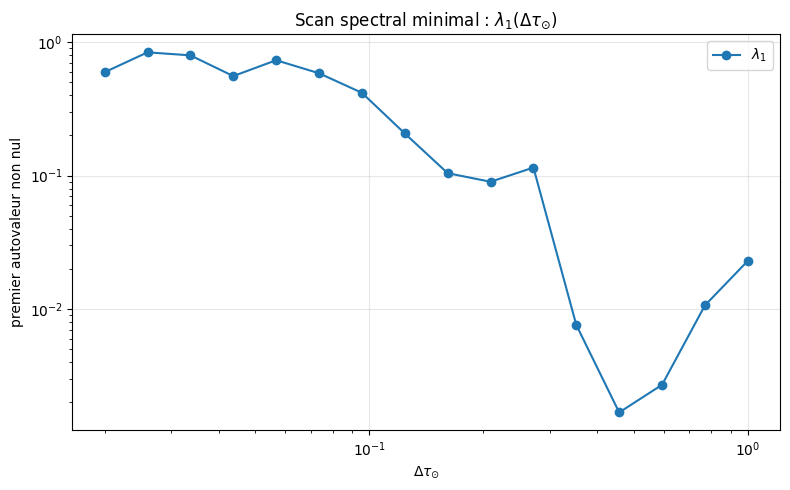

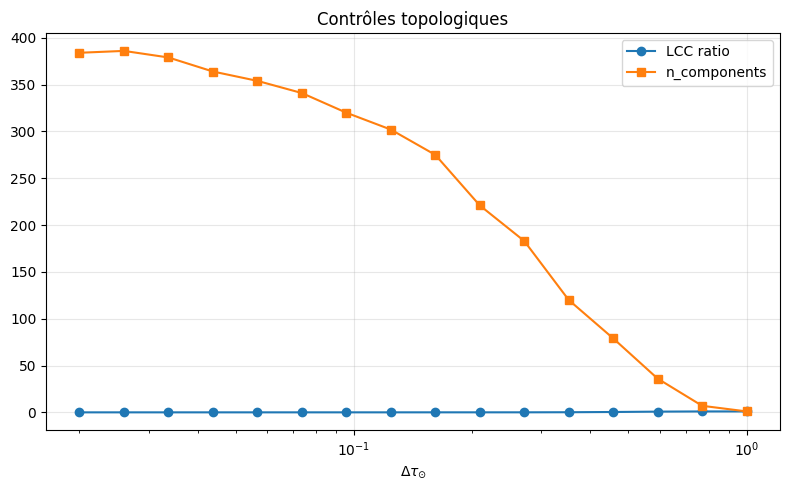

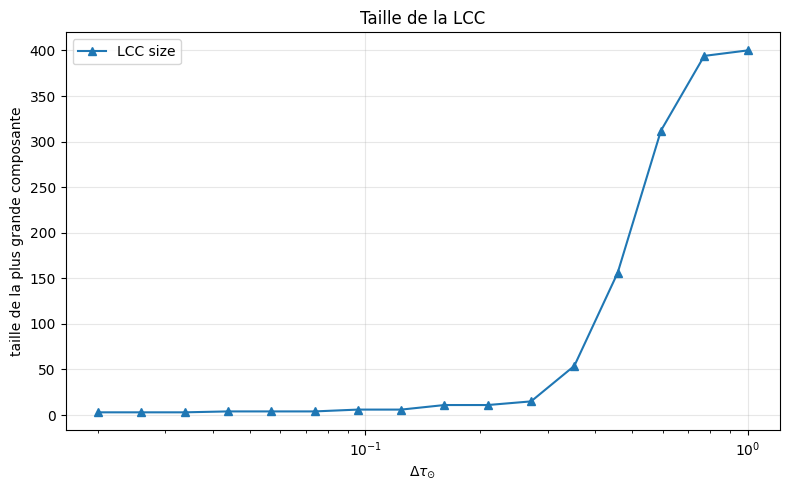

In [13]:
# ============================================================
# ET_fractal — scan spectral minimal de lambda1(Δτ⊙)
# Convention :
#   lambda1 = plus petit autovaleur STRICTEMENT positif du Laplacien
#   (donc "algebraic connectivity" au sens de Fiedler)
# ============================================================

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Iterable, Optional

import numpy as np
import scipy.sparse as sp
from scipy.sparse.csgraph import laplacian, connected_components
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigvalsh
import matplotlib.pyplot as plt


# ---------------------------
# Structures de sortie
# ---------------------------

@dataclass
class SpectralPoint:
    tau: float
    n_nodes: int
    n_edges: int
    n_components: int
    lcc_ratio: float
    lcc_size: int
    lambda0_mult: int
    lambda1: float                  # premier autovaleur > 0
    lambda2: Optional[float] = None # deuxième autovaleur > 0 si dispo
    degree_mean: Optional[float] = None
    degree_max: Optional[float] = None


# ---------------------------
# Outils de base
# ---------------------------

def ensure_symmetric_adjacency(A: sp.spmatrix, *, rtol: float = 1e-10) -> sp.csr_matrix:
    """
    Symétrise une matrice d'adjacence pondérée si nécessaire.
    Dans ET_fractal, si les conductances sont censées être réciproques,
    c'est la version à utiliser.
    """
    A = A.tocsr().astype(float)
    if A.shape[0] != A.shape[1]:
        raise ValueError("Adjacency matrix must be square.")
    if (A - A.T).nnz > 0:
        # symétrisation conservative
        A = 0.5 * (A + A.T)
    A.sum_duplicates()
    A.eliminate_zeros()
    return A


def largest_connected_component(A: sp.csr_matrix) -> tuple[sp.csr_matrix, np.ndarray]:
    """
    Extrait la plus grande composante connexe.
    Utile si tu veux comparer lambda1 sur le graphe complet
    et sur la composante géante.
    """
    n_comp, labels = connected_components(A, directed=False, connection='weak')
    if n_comp == 1:
        idx = np.arange(A.shape[0])
        return A, idx

    counts = np.bincount(labels)
    biggest = np.argmax(counts)
    idx = np.where(labels == biggest)[0]
    A_sub = A[idx][:, idx].tocsr()
    return A_sub, idx


def positive_laplacian_eigs(
    A: sp.csr_matrix,
    *,
    normed: bool = False,
    k: int = 6,
    tol: float = 1e-8,
    zero_tol: float = 1e-10,
    dense_threshold: int = 80,
) -> tuple[np.ndarray, Optional[np.ndarray]]:
    """
    Calcule quelques plus petits autovaleurs du Laplacien et renvoie
    les autovaleurs strictement positives + vecteurs propres associés.

    Correction :
    - solveur exact dense pour petites matrices
    - solveur sparse pour grandes matrices

    Notes:
    - SciPy `laplacian` construit le Laplacien du graphe.
    - `eigsh` convient aux matrices réelles symétriques sparse.
    """
    if A.shape[0] < 2:
        raise ValueError("Graph must have at least 2 nodes.")

    L = laplacian(A, normed=normed).tocsr()
    n = L.shape[0]

    # ---- Cas petite matrice : solveur exact dense
    if n <= dense_threshold:
        vals = np.sort(eigvalsh(L.toarray()))
        positive = vals > zero_tol
        return vals[positive], None

    # ---- Cas grande matrice : solveur sparse
    k_eff = min(max(2, k), n - 1)

    # On cherche les plus petits en magnitude
    vals, vecs = eigsh(L, k=k_eff, which="SM", tol=tol)
    order = np.argsort(vals)
    vals = vals[order]
    vecs = vecs[:, order]

    positive = vals > zero_tol
    return vals[positive], vecs[:, positive]


def spectral_summary_for_graph(
    tau: float,
    A: sp.spmatrix,
    *,
    normed: bool = False,
    use_lcc: bool = False,
    eig_k: int = 6,
    eig_tol: float = 1e-8,
    zero_tol: float = 1e-10,
    dense_threshold: int = 80,
    min_lcc_size_for_lambda: int = 2,
) -> SpectralPoint:
    """
    Résumé spectral minimal pour un graphe pondéré ET_fractal.
    """
    A = ensure_symmetric_adjacency(A)
    A = A.tocsr()

    n = A.shape[0]
    deg = np.array(A.sum(axis=1)).ravel()
    degree_mean = float(np.mean(deg)) if n > 0 else np.nan
    degree_max = float(np.max(deg)) if n > 0 else np.nan
    n_edges = int(A.nnz // 2)

    n_comp, labels = connected_components(A, directed=False, connection='weak')
    counts = np.bincount(labels)
    lcc_size = int(counts.max()) if len(counts) > 0 else 0
    lcc_ratio = float(lcc_size / n) if n > 0 else np.nan

    A_eval = A
    if use_lcc:
        A_eval, _ = largest_connected_component(A_eval)

    # multiplicité de 0 = nombre de composantes connexes
    # sur le graphe complet, pas forcément sur la LCC
    lambda0_mult = int(n_comp)

    # Si on travaille sur la LCC mais qu'elle est trop petite,
    # mieux vaut ne pas sur-interpréter lambda1.
    if use_lcc and A_eval.shape[0] < min_lcc_size_for_lambda:
        lambda1 = np.nan
        lambda2 = None
    else:
        pos_vals, _ = positive_laplacian_eigs(
            A_eval,
            normed=normed,
            k=eig_k,
            tol=eig_tol,
            zero_tol=zero_tol,
            dense_threshold=dense_threshold,
        )

        lambda1 = float(pos_vals[0]) if len(pos_vals) >= 1 else 0.0
        lambda2 = float(pos_vals[1]) if len(pos_vals) >= 2 else None

    return SpectralPoint(
        tau=float(tau),
        n_nodes=n,
        n_edges=n_edges,
        n_components=n_comp,
        lcc_ratio=lcc_ratio,
        lcc_size=lcc_size,
        lambda0_mult=lambda0_mult,
        lambda1=lambda1,
        lambda2=lambda2,
        degree_mean=degree_mean,
        degree_max=degree_max,
    )


# ---------------------------
# Interface ET_fractal
# ---------------------------

def run_lambda1_scan(
    tau_values: Iterable[float],
    graph_builder: Callable[[float], sp.spmatrix],
    *,
    normed: bool = False,
    use_lcc: bool = False,
    eig_k: int = 6,
    eig_tol: float = 1e-8,
    zero_tol: float = 1e-10,
    dense_threshold: int = 80,
    min_lcc_size_for_lambda: int = 2,
    verbose: bool = True,
) -> list[SpectralPoint]:
    """
    graph_builder(tau) doit renvoyer la matrice d'adjacence sparse pondérée
    associée à la configuration ET_fractal à résolution tau.

    Exemple attendu :
        A = graph_builder(tau)
        # A[i,j] = conductance / poids entre i et j
    """
    results: list[SpectralPoint] = []

    for tau in tau_values:
        A = graph_builder(float(tau))
        point = spectral_summary_for_graph(
            tau=float(tau),
            A=A,
            normed=normed,
            use_lcc=use_lcc,
            eig_k=eig_k,
            eig_tol=eig_tol,
            zero_tol=zero_tol,
            dense_threshold=dense_threshold,
            min_lcc_size_for_lambda=min_lcc_size_for_lambda,
        )
        results.append(point)

        if verbose:
            l1_str = f"{point.lambda1:.6e}" if np.isfinite(point.lambda1) else "nan"
            print(
                f"tau={point.tau:.6g} | "
                f"N={point.n_nodes} E={point.n_edges} | "
                f"comp={point.n_components} lcc={point.lcc_ratio:.3f} "
                f"(size={point.lcc_size}) | "
                f"lambda1={l1_str}"
            )

    return results


# ---------------------------
# Visualisation
# ---------------------------

def plot_lambda1_scan(results: list[SpectralPoint], *, logx: bool = True, logy: bool = True) -> None:
    tau = np.array([r.tau for r in results], dtype=float)
    lam1 = np.array([r.lambda1 for r in results], dtype=float)
    lcc = np.array([r.lcc_ratio for r in results], dtype=float)
    lcc_size = np.array([r.lcc_size for r in results], dtype=float)
    comps = np.array([r.n_components for r in results], dtype=float)

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)
    ax.plot(tau, lam1, marker="o", label=r"$\lambda_1$")
    ax.set_xlabel(r"$\Delta\tau_{\odot}$")
    ax.set_ylabel(r"premier autovaleur non nul")
    ax.set_title(r"Scan spectral minimal : $\lambda_1(\Delta\tau_{\odot})$")
    if logx:
        ax.set_xscale("log")
    if logy:
        finite_vals = lam1[np.isfinite(lam1) & (lam1 > 0)]
        if len(finite_vals) > 0:
            ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)
    ax.plot(tau, lcc, marker="o", label="LCC ratio")
    ax.plot(tau, comps, marker="s", label="n_components")
    ax.set_xlabel(r"$\Delta\tau_{\odot}$")
    ax.set_title("Contrôles topologiques")
    if logx:
        ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)
    ax.plot(tau, lcc_size, marker="^", label="LCC size")
    ax.set_xlabel(r"$\Delta\tau_{\odot}$")
    ax.set_ylabel("taille de la plus grande composante")
    ax.set_title("Taille de la LCC")
    if logx:
        ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


# ---------------------------
# Exemple de branchage
# ---------------------------

def example_graph_builder(tau: float) -> sp.csr_matrix:
    """
    PLACEHOLDER.
    À remplacer par ton pipeline ET_fractal.

    Tu dois renvoyer une matrice d'adjacence sparse pondérée.
    Idéalement:
      - sommets = cellules / blocs coarse-grainés
      - poids = conductances effectives c_xy
    """
    rng = np.random.default_rng(int(1e6 * tau) % (2**32 - 1))

    # Exemple jouet : grille 2D dont on retire des arêtes de plus en plus
    # quand tau diminue. Purement illustratif.
    side = 20
    n = side * side
    rows, cols, data = [], [], []

    def idx(i: int, j: int) -> int:
        return i * side + j

    # probabilité d'arête active jouet
    p_active = min(1.0, max(0.02, tau))

    for i in range(side):
        for j in range(side):
            u = idx(i, j)
            for di, dj in [(1, 0), (0, 1)]:
                ni, nj = i + di, j + dj
                if ni < side and nj < side:
                    if rng.random() < p_active:
                        v = idx(ni, nj)
                        w = 0.5 + rng.random()
                        rows += [u, v]
                        cols += [v, u]
                        data += [w, w]

    A = sp.csr_matrix((data, (rows, cols)), shape=(n, n))
    return A


# ---------------------------
# Lancement
# ---------------------------

if __name__ == "__main__":
    tau_values = np.geomspace(0.02, 1.0, 16)

    results = run_lambda1_scan(
        tau_values=tau_values,
        graph_builder=example_graph_builder,  # <-- remplace par ton builder
        normed=False,   # mets True si tu veux aussi tester le Laplacien normalisé
        use_lcc=True,   # conseillé ici pour suivre la plus grande composante
        eig_k=6,
        eig_tol=1e-8,
        zero_tol=1e-10,
        dense_threshold=80,
        min_lcc_size_for_lambda=2,
        verbose=True,
    )

    plot_lambda1_scan(results, logx=True, logy=True)